## Setup

In [1]:
import os
import ast
import random
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../")))

PATH_TO_DATASET = os.path.abspath(
    os.path.join(os.getcwd(), "../../dataset/artificial data")
)

lst_files = os.listdir(PATH_TO_DATASET)

for f_name in lst_files:
    print(f_name)

dna_10.txt
dna_1280.txt
dna_160.txt
dna_20.txt
dna_320.txt
dna_40.txt
dna_640.txt
dna_80.txt


In [2]:
PATH_FILES = [os.path.join(PATH_TO_DATASET, i) for i in lst_files]

for f_path in PATH_FILES:
    print(f_path)

d:\Project\data\project\dna-matching\dataset\artificial data\dna_10.txt
d:\Project\data\project\dna-matching\dataset\artificial data\dna_1280.txt
d:\Project\data\project\dna-matching\dataset\artificial data\dna_160.txt
d:\Project\data\project\dna-matching\dataset\artificial data\dna_20.txt
d:\Project\data\project\dna-matching\dataset\artificial data\dna_320.txt
d:\Project\data\project\dna-matching\dataset\artificial data\dna_40.txt
d:\Project\data\project\dna-matching\dataset\artificial data\dna_640.txt
d:\Project\data\project\dna-matching\dataset\artificial data\dna_80.txt


In [3]:
input_strings = []
patterns = []
num_of_misses = []
result = []

for f_path in PATH_FILES:
    with open(f_path, 'r') as f:
        lines = f.readlines()

        for line in lines:
            line = line.strip()
            if not line:
                continue
            elements = line.split(' ', maxsplit=3)

            input_strings.append(elements[0])
            patterns.append(elements[1])
            num_of_misses.append(int(elements[2]))
            result.append(ast.literal_eval(elements[3]))

In [4]:
seed = 42
n_samples = 10

random.seed(seed)

indices = random.sample(range(len(input_strings)), min(n_samples, len(input_strings)))

print('Example:')

for idx, i in enumerate(indices, start=1):
    print(f"Sample {idx}:")
    print("Input string:", input_strings[i])
    print("Pattern:", patterns[i])
    print("Num of misses:", num_of_misses[i])
    print("Result:", result[i])
    print("-" * 50)

Example:
Sample 1:
Input string: GCCACGCCAGCACGATAAAGGTTGGGCGACGAGTGCGTACTTCACGGTCGAGATCGAACAGTTATATCACACTCAAAACGGGTAGTACTACCTGCTCGTTTGGGTTGATGCTTTCAAATAAGTGGAAAATACGACCCTCGATAGGTGTAACGGGATGCTCCGGTAGGACTGAGGATACCTACCTCACAAATAGTTGTACGTACACGTCCATTGGGCACACGAGCTTCTGAAGAGACACCCATATGTATGGCTCGGGCAGTGCGACGGGACGATTCTCCAGTCCCAGGGCGCGGTTCCGACCCTGCGCATTTGGAGTGATAATTAATCAGTTGGATGATACATTTCGTCGCGGTATTGAGGTGAACTCTTAGAAAAAGACCAAACAGGAAGATCGCAGTTCAATTGTTATTCGATGATGCCCTAGGGGCCACAGCTTACAGCACAAAGGGTTTAGAGGGGCTCTGCGCTGTGCCTTATTCCCTCGATAGTACACCATCATCTCAACTTTATGGGGCCAGGGGTTATCTGGCTATCCAGTGATCACAAATTATTATAATTCGGCTCGAATATTTGGATTGCGTCTCTACGCAGTCGCCACATCGCAAGGTCACACACTATCGGCCCCCCCACCTGGCCCGGCCCCGCTAACAGGTAGAACGACACGTAGCTTGGTAGACCGTTGACTAGAAACGCCTACGTCGGTCCGACTCAGAGCAAACAGTCGGTAGTATGGGGGCTTCGCCCCGAATTGTTGCACCATCTGCACATGTATACGCTATCGAGGCTCTGGTGAACGTCAAGCAGGAAATGATACAGTCTACTTTAGCCATAATCGCCTTGGCTTCTCCGCCCTACCAGAATCGCTGAAAACGACGGTGCTTATTTTTCAGCCAGTCTTCGATGCCGCATAGAGCATCCCGTGTCTGCTCCCAAGAGACCAATTGAGTCTTAAACATAATGAATCCCC

## Experiment

In [5]:
def valid(pred, expected):
    return sorted(pred) == sorted(expected)

def print_random_samples(input_strings, patterns, num_of_misses, result, seed=42, n_samples=10):
    random.seed(seed)

    indices = random.sample(
        range(len(input_strings)),
        min(n_samples, len(input_strings))
    )

    print(f"{len(indices)} sample with seed = {seed}")
    print()

    for idx, i in enumerate(indices, start=1):
        print(f"Sample {idx}")
        print("Text       :", input_strings[i])
        print("Pattern    :", patterns[i])
        print("k          :", num_of_misses[i])
        print("Expected   :", result[i])
        print()

In [6]:
print_random_samples(
    input_strings,
    patterns,
    num_of_misses,
    result,
    seed=42,
    n_samples=10
)

10 sample with seed = 42

Sample 1
Text       : GCCACGCCAGCACGATAAAGGTTGGGCGACGAGTGCGTACTTCACGGTCGAGATCGAACAGTTATATCACACTCAAAACGGGTAGTACTACCTGCTCGTTTGGGTTGATGCTTTCAAATAAGTGGAAAATACGACCCTCGATAGGTGTAACGGGATGCTCCGGTAGGACTGAGGATACCTACCTCACAAATAGTTGTACGTACACGTCCATTGGGCACACGAGCTTCTGAAGAGACACCCATATGTATGGCTCGGGCAGTGCGACGGGACGATTCTCCAGTCCCAGGGCGCGGTTCCGACCCTGCGCATTTGGAGTGATAATTAATCAGTTGGATGATACATTTCGTCGCGGTATTGAGGTGAACTCTTAGAAAAAGACCAAACAGGAAGATCGCAGTTCAATTGTTATTCGATGATGCCCTAGGGGCCACAGCTTACAGCACAAAGGGTTTAGAGGGGCTCTGCGCTGTGCCTTATTCCCTCGATAGTACACCATCATCTCAACTTTATGGGGCCAGGGGTTATCTGGCTATCCAGTGATCACAAATTATTATAATTCGGCTCGAATATTTGGATTGCGTCTCTACGCAGTCGCCACATCGCAAGGTCACACACTATCGGCCCCCCCACCTGGCCCGGCCCCGCTAACAGGTAGAACGACACGTAGCTTGGTAGACCGTTGACTAGAAACGCCTACGTCGGTCCGACTCAGAGCAAACAGTCGGTAGTATGGGGGCTTCGCCCCGAATTGTTGCACCATCTGCACATGTATACGCTATCGAGGCTCTGGTGAACGTCAAGCAGGAAATGATACAGTCTACTTTAGCCATAATCGCCTTGGCTTCTCCGCCCTACCAGAATCGCTGAAAACGACGGTGCTTATTTTTCAGCCAGTCTTCGATGCCGCATAGAGCATCCCGTGTCTGCTCCCAAGAGACCAATTGAGTCTTAA

In [7]:
import pandas as pd

def test_algorithm_on_file(algo, f_path):
    records = []

    for i in range(len(input_strings)):
        text = input_strings[i]
        pattern = patterns[i]
        k = num_of_misses[i]
        expected = result[i]

        eval_result = algo.evaluate(text, pattern, k)
        pred = eval_result["matches"]

        records.append({
            "file": os.path.basename(f_path),
            "input_size": len(text),
            "sample_id": i,
            "algorithm": algo.name,
            "text_len": len(text),
            "pattern_len": len(pattern),
            "k": k,
            "runtime_sec": eval_result["runtime_sec"],
            "num_expected": len(expected),
            "num_pred": eval_result["num_matches"],
            "valid": valid(pred, expected),
            "expected": expected,
            "pred": pred,
        })

    return pd.DataFrame(records)

### Rabin-Karp with Verification

In [8]:
from rabin_karp import RabinKarp
algo = RabinKarp()

all_dfs = []

for f_path in PATH_FILES:
    df_file = test_algorithm_on_file(algo, f_path)
    all_dfs.append(df_file)

df_all = pd.concat(all_dfs, ignore_index=True)

df_all.head()

,file,input_size,sample_id,algorithm,text_len,pattern_len,k,runtime_sec,num_expected,num_pred,valid,expected,pred
0,dna_10.txt,10,0,Rabin-Karp with Verification,10,3,0,0.000056,1,1,True,[1],[1]
1,dna_10.txt,10,1,Rabin-Karp with Verification,10,3,0,0.000012,1,1,True,[3],[3]
2,dna_10.txt,10,2,Rabin-Karp with Verification,10,3,0,0.000011,1,1,True,[6],[6]
3,dna_10.txt,10,3,Rabin-Karp with Verification,10,3,1,0.000015,2,2,True,"[2, 3]","[2, 3]"
4,dna_10.txt,10,4,Rabin-Karp with Verification,10,3,0,0.000007,1,1,True,[1],[1]


In [9]:
summary = df_all.groupby("input_size").agg(
    num_samples=("sample_id", "count"),
    num_correct=("valid", "sum"),
    avg_runtime_sec=("runtime_sec", "mean"),
    median_runtime_sec=("runtime_sec", "median"),
    min_runtime_sec=("runtime_sec", "min"),
    max_runtime_sec=("runtime_sec", "max"),
    total_runtime_sec=("runtime_sec", "sum"),
    avg_pattern_len=("pattern_len", "mean"),
    avg_k=("k", "mean"),
).reset_index()

summary["num_wrong"] = summary["num_samples"] - summary["num_correct"]
summary["accuracy"] = summary["num_correct"] / summary["num_samples"]

summary

,input_size,num_samples,num_correct,avg_runtime_sec,median_runtime_sec,min_runtime_sec,max_runtime_sec,total_runtime_sec,avg_pattern_len,avg_k,num_wrong,accuracy
0,10,80,80,0.000009,0.000007,0.000006,0.000056,0.000689,3.0,0.3,0,1.0
1,20,80,80,0.000013,0.000011,0.000010,0.000028,0.001013,3.0,0.3,0,1.0
2,40,80,80,0.000025,0.000022,0.000020,0.000062,0.002007,4.0,0.2,0,1.0
3,80,80,80,0.000060,0.000059,0.000040,0.000208,0.004794,8.0,0.7,0,1.0
4,160,80,80,0.000213,0.000207,0.000162,0.000501,0.017072,16.0,3.5,0,1.0
5,320,80,80,0.000552,0.000565,0.000383,0.001043,0.044126,32.0,6.5,0,1.0
6,640,80,80,0.001498,0.001531,0.000741,0.002261,0.119870,64.0,11.9,0,1.0
7,1280,80,80,0.004787,0.005035,0.002451,0.008084,0.382967,128.0,25.7,0,1.0


In [10]:
def show_random_samples(df_all, seed=42, n_samples=10):
    random.seed(seed)

    indices = random.sample(
        list(df_all.index),
        min(n_samples, len(df_all))
    )

    for idx, row_id in enumerate(indices, start=1):
        row = df_all.loc[row_id]

        print(f"Sample {idx}")
        print("File       :", row["file"])
        print("Input size :", row["input_size"])
        print("Text len   :", row["text_len"])
        print("Pattern len:", row["pattern_len"])
        print("k          :", row["k"])
        print("Expected   :", row["expected"])
        print("Predicted  :", row["pred"])
        print("Runtime    :", row["runtime_sec"])
        print("Valid      :", row["valid"])
        print("-" * 80)


show_random_samples(df_all, seed=42, n_samples=10)

Sample 1
File       : dna_1280.txt
Input size : 20
Text len   : 20
Pattern len: 3
k          : 0
Expected   : [5]
Predicted  : [5]
Runtime    : 1.0600000678095967e-05
Valid      : True
--------------------------------------------------------------------------------
Sample 2
File       : dna_10.txt
Input size : 160
Text len   : 160
Pattern len: 16
k          : 2
Expected   : [61]
Predicted  : [61]
Runtime    : 0.00020370000129332766
Valid      : True
--------------------------------------------------------------------------------
Sample 3
File       : dna_20.txt
Input size : 320
Text len   : 320
Pattern len: 32
k          : 7
Expected   : [20]
Predicted  : [20]
Runtime    : 0.0005530999987968244
Valid      : True
--------------------------------------------------------------------------------
Sample 4
File       : dna_20.txt
Input size : 1280
Text len   : 1280
Pattern len: 128
k          : 24
Expected   : [422]
Predicted  : [422]
Runtime    : 0.005114699997648131
Valid      : True
-----

In [11]:
wrong_df = df_all[df_all["valid"] == False]

print("Số mẫu sai:", len(wrong_df))

wrong_df[[
    "file",
    "input_size",
    "sample_id",
    "pattern_len",
    "k",
    "expected",
    "pred",
    "runtime_sec"
]].head(10)

Số mẫu sai: 0


,file,input_size,sample_id,pattern_len,k,expected,pred,runtime_sec


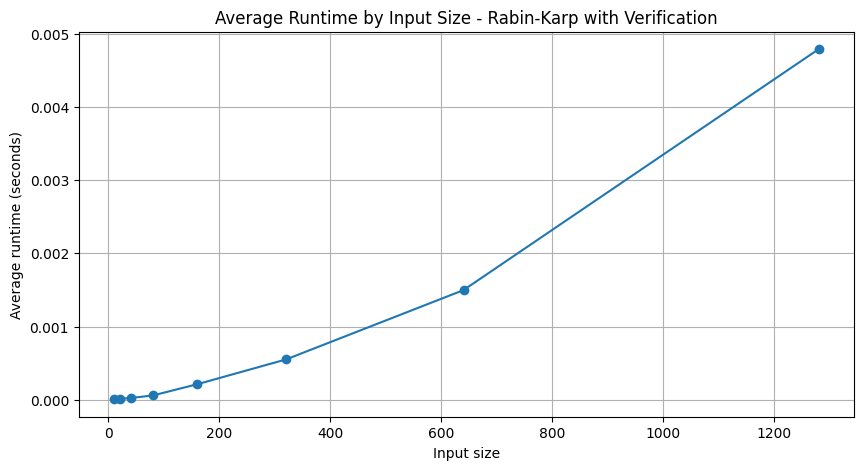

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(summary["input_size"], summary["avg_runtime_sec"], marker="o")
plt.xlabel("Input size")
plt.ylabel("Average runtime (seconds)")
plt.title(f"Average Runtime by Input Size - {algo.name}")
plt.grid(True)
plt.show()

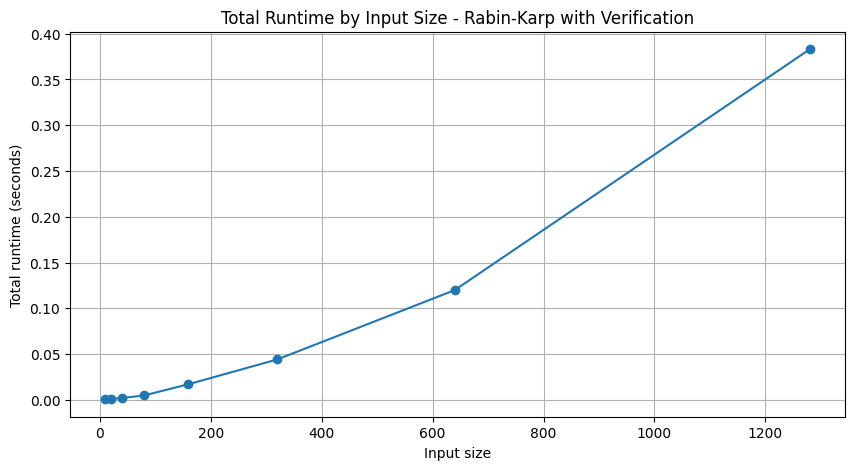

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(summary["input_size"], summary["total_runtime_sec"], marker="o")
plt.xlabel("Input size")
plt.ylabel("Total runtime (seconds)")
plt.title(f"Total Runtime by Input Size - {algo.name}")
plt.grid(True)
plt.show()

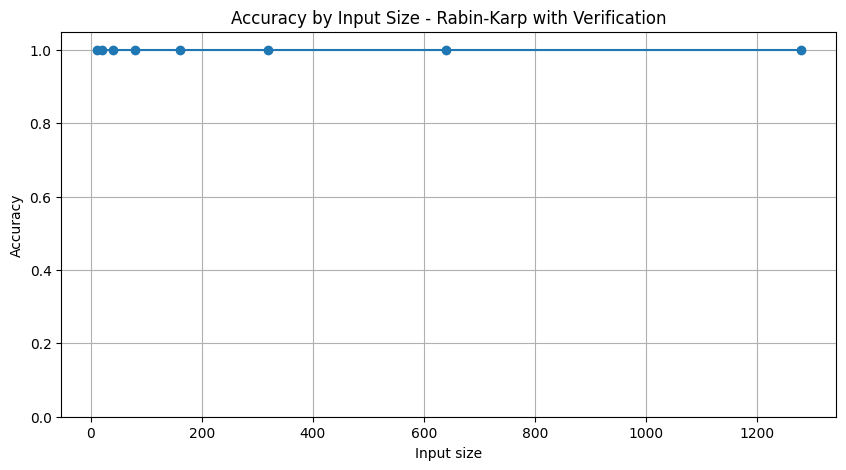

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(summary["input_size"], summary["accuracy"], marker="o")
plt.xlabel("Input size")
plt.ylabel("Accuracy")
plt.title(f"Accuracy by Input Size - {algo.name}")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

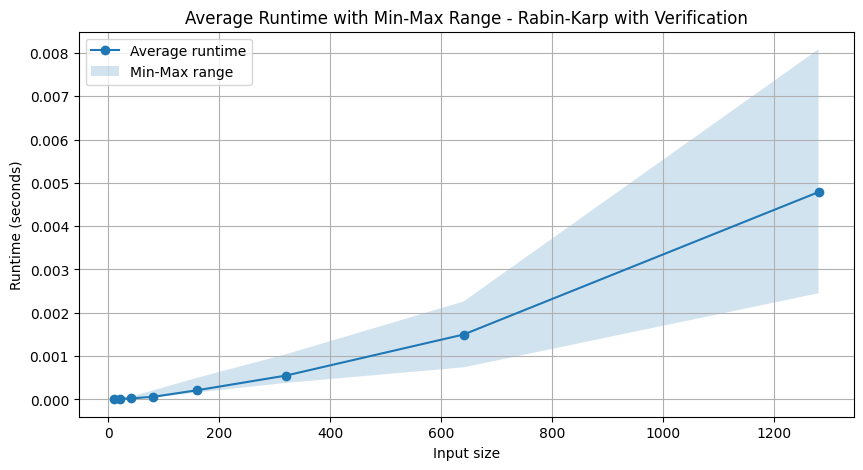

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(
    summary["input_size"],
    summary["avg_runtime_sec"],
    marker="o",
    label="Average runtime"
)

plt.fill_between(
    summary["input_size"],
    summary["min_runtime_sec"],
    summary["max_runtime_sec"],
    alpha=0.2,
    label="Min-Max range"
)

plt.xlabel("Input size")
plt.ylabel("Runtime (seconds)")
plt.title(f"Average Runtime with Min-Max Range - {algo.name}")
plt.grid(True)
plt.legend()
plt.show()